In [1]:
%load_ext autoreload
%autoreload 2

# Imports

In [2]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from IPython.display import display
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split

from src.pipelines import create_pipeline, evaluate_model, prepare_data, save_results

warnings.filterwarnings('ignore', category=UserWarning)

## Data Preparation for Further Work

In [3]:
raw_df = pd.read_csv(
    "../data/bank-additional-full.csv",
    sep=";"
)

# splitting data into train and validation sets in an 80/20 ratio
train_df, val_df = train_test_split(raw_df, test_size=0.2, random_state=42, stratify=raw_df['y'])

train_df = train_df.copy()
val_df = val_df.copy()

# create mapping column 'yes' = 1, 'no' = 0
train_df['y_num'] = train_df['y'].map({'yes': 1, 'no': 0})
val_df['y_num'] = val_df['y'].map({'yes': 1, 'no': 0})

# creating target mapping column 'yes' = 1, 'no' = 0
input_cols = [col for col in train_df.columns if col not in ['y', 'y_num']]

target_col = 'y_num'
target_cat_col = 'y'

# Analysis of the selected final model

In [4]:
# data formation
train_lgbm = train_df.copy()
val_lgbm = val_df.copy()

input_cols_lgbm = [col for col in train_lgbm.columns if col not in ['y', 'y_num']]
drop_cols = ['duration']

X_train, y_train, X_val, y_val, num_features, cat_features = prepare_data(
    train_df=train_lgbm,
    val_df=val_lgbm,
    input_cols=input_cols_lgbm,
    target_col=target_col,
    drop_cols=drop_cols)

In [ ]:
# model
lgbm_model = create_pipeline(
    model=LGBMClassifier(
        random_state=42,
        n_estimators=100,
        learning_rate=0.05,
        max_depth=-1,
        is_unbalance=True,
        num_leaves=31,
        min_child_samples=20,
        reg_alpha=0.1,
        reg_lambda=0.1
    ),
    numeric_cols=num_features,
    categorical_cols=cat_features,
    model_type='lightgbm',
)

lgbm_model.fit(X_train, y_train)


=== LightGBM ===
Classification report (validation):
              precision    recall  f1-score   support

           0       0.95      0.88      0.92      7310
           1       0.41      0.66      0.51       928

    accuracy                           0.86      8238
   macro avg       0.68      0.77      0.71      8238
weighted avg       0.89      0.86      0.87      8238

Confusion matrix (validation):
[[6441  869]
 [ 316  612]]
Train AUROC: 0.8536
Validation AUROC: 0.8208


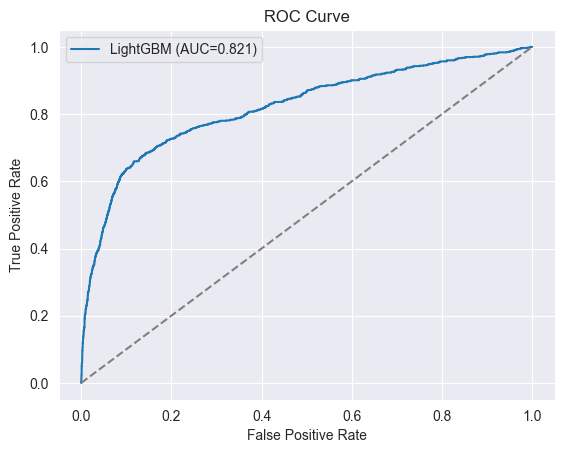

In [21]:
lgbm_results = pd.read_csv('../outputs/lgbm_results.csv')

# comment on the results table
new_comment = 'Best model'

# evaluation of result
lgbm_results = evaluate_model(
    model_name='LightGBM',
    model=lgbm_model,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    params=lgbm_model.get_params(),
    comments=new_comment,
    results_table=lgbm_results
)

In [17]:
# threshold selection
y_val_proba = lgbm_model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred = (y_val_proba >= t).astype(int)

    f1 = f1_score(y_val, y_pred)

    results.append({
        'threshold': round(t, 2),
        'f1_score': f1
    })

threshold_df = pd.DataFrame(results).sort_values(by='f1_score', ascending=False)

threshold_df

,threshold,f1_score
11,0.65,0.531041
10,0.60,0.529546
12,0.70,0.529032
9,0.55,0.524298
13,0.75,0.520231
8,0.50,0.508095
7,0.45,0.482916
14,0.80,0.472050
6,0.40,0.441678
15,0.85,0.404207


In [18]:
# best classification threshold
best_threshold = threshold_df.iloc[0]['threshold']
best_threshold

np.float64(0.65)

In [19]:
# final metrics with best_threshold
y_val_pred_opt = (y_val_proba >= best_threshold).astype(int)

print(classification_report(y_val, y_val_pred_opt))
print('F1:', f1_score(y_val, y_val_pred_opt))

              precision    recall  f1-score   support

           0       0.95      0.92      0.93      7310
           1       0.48      0.60      0.53       928

    accuracy                           0.88      8238
   macro avg       0.71      0.76      0.73      8238
weighted avg       0.89      0.88      0.89      8238

F1: 0.5310410697230181


Additionally, the classification threshold was tuned, which allowed modifying additional metrics at threshold=0.65:
* Precision increased from 0.41 to 0.48, thus reducing the number of false positive cases
* At the same time, Recall decreased from 0.66 to 0.60, meaning the number of true positive cases decreased
* F1-score increased from 0.51 to 0.53, making the model more balanced
* Accuracy, macro avg F1, and weighted avg metrics also increased.

# Feature Importance Analysis

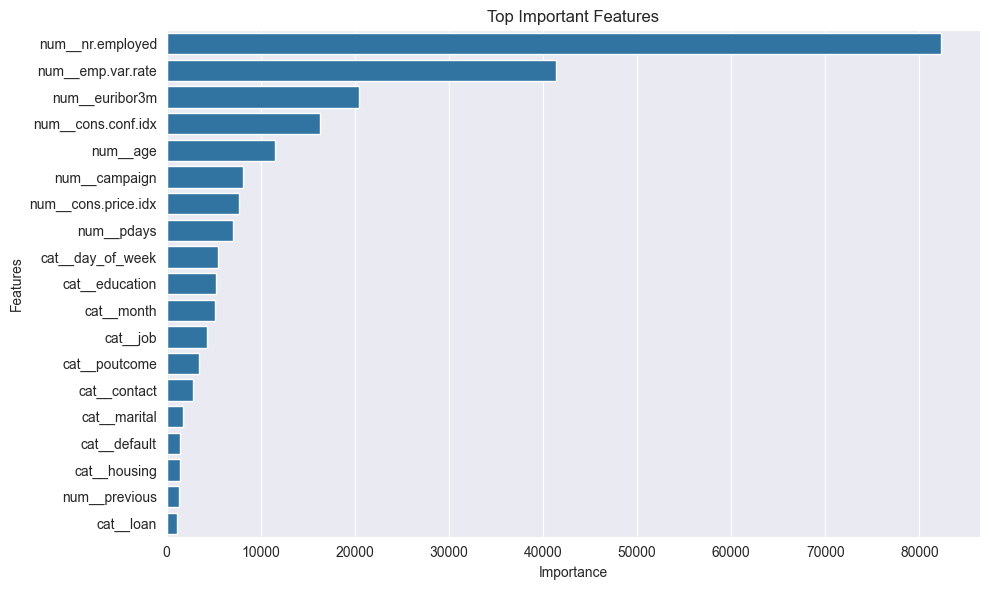

                feature    importance
8      num__nr.employed  82329.560008
4     num__emp.var.rate  41421.052789
7        num__euribor3m  20414.570851
6    num__cons.conf.idx  16283.818325
0              num__age  11542.886812
1         num__campaign   8156.252904
5   num__cons.price.idx   7662.073243
2            num__pdays   7104.807400
17     cat__day_of_week   5450.220417
11       cat__education   5214.864899
16           cat__month   5170.822080
9              cat__job   4300.484853
18        cat__poutcome   3390.188483
15         cat__contact   2839.310398
10         cat__marital   1787.972493
12         cat__default   1435.223952
13         cat__housing   1429.530117
3         num__previous   1312.327377
14            cat__loan   1129.229440


In [20]:
# features after preprocessing
feature_names = lgbm_model.named_steps['preprocessor'].get_feature_names_out()

# LightGBM model
booster = lgbm_model.named_steps['model']

importance = booster.booster_.feature_importance(importance_type='gain')
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
})

importance_df = importance_df.sort_values(by='importance', ascending=False)

# top features
top_features = importance_df.head(20)

# visualization
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_features,
    x='importance',
    y='feature'
)
plt.title('Top Important Features')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

print(top_features)

Based on the feature importance plot for the LightGBM model, the following conclusions can be drawn:

* The feature 'nr.employed' has the largest contribution to the prediction, with its importance significantly exceeding all others.
* Macroeconomic indicators make the most significant contribution to the model: 'nr.employed', 'emp.var.rate', 'euribor3m', and 'cons.conf.idx'.
* Age ('age') and contact intensity within the current campaign ('campaign') are the most important features among individual client characteristics.
* Features 'loan', 'housing', 'default', and 'previous' have low importance.

Overall, the feature importance analysis aligns with the EDA results: macroeconomic indicators and client interaction intensity have a substantial impact. The obtained results also make business sense: economic conditions influence clients' financial decisions, and the contact strategy can significantly impact the outcome of the marketing campaign.


## Additional Analysis

### Removal of the 'nr.employed' feature to evaluate the impact of correlation among macroeconomic features

[LightGBM] [Info] Number of positive: 3712, number of negative: 29238
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004670 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 409
[LightGBM] [Info] Number of data points in the train set: 32950, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112656 -> initscore=-2.063898
[LightGBM] [Info] Start training from score -2.063898

=== LGBM without nr.employed ===
Classification report (validation):
              precision    recall  f1-score   support

           0       0.91      0.98      0.95      7310
           1       0.68      0.28      0.39       928

    accuracy                           0.90      8238
   macro avg       0.80      0.63      0.67      8238
weighted avg       0.89      0.90      0.89      8238

Confusion matrix (validation):
[[7188  122]
 [ 

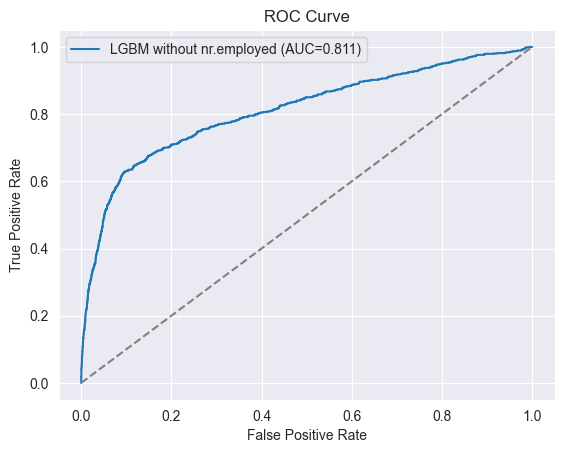

,Model,Params,Train_AUROC,Val_AUROC,Train_F1,Val_F1,Comments
0,LGBM without nr.employed,None,0.8748,0.8114,0.4579,0.3945,None


In [12]:
drop_feature = 'nr.employed'

# new column list
input_cols_drop = [col for col in input_cols_lgbm if col != drop_feature]

X_train_d, y_train_d, X_val_d, y_val_d, num_f_d, cat_f_d = prepare_data(
    train_df=train_lgbm,
    val_df=val_lgbm,
    input_cols=input_cols_drop,
    target_col=target_col,
    drop_cols=drop_cols
)

# new model
lgbm_drop = create_pipeline(
    model=LGBMClassifier(random_state=42),
    numeric_cols=num_f_d,
    categorical_cols=cat_f_d,
    model_type='lightgbm'
)

lgbm_drop.fit(X_train_d, y_train_d)

evaluate_model(
    'LGBM without nr.employed',
    lgbm_drop,
    X_train_d, y_train_d,
    X_val_d, y_val_d
)

Removing the 'nr.employed' feature did not lead to a significant drop in AUROC, indicating that the model is not entirely dependent on this feature.
At the same time, the substantial decrease in the F1-score indicates that this feature has a significant impact on the final prediction (helping the model better identify the positive class).

### Removal of features 'nr.employed', 'emp.var.rate', 'euribor3m' to evaluate the impact of correlation among macroeconomic features

[LightGBM] [Info] Number of positive: 3712, number of negative: 29238
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007995 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 244
[LightGBM] [Info] Number of data points in the train set: 32950, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112656 -> initscore=-2.063898
[LightGBM] [Info] Start training from score -2.063898

=== LGBM without nr.employed ===
Classification report (validation):
              precision    recall  f1-score   support

           0       0.91      0.98      0.95      7310
           1       0.66      0.25      0.36       928

    accuracy                           0.90      8238
   macro avg       0.79      0.61      0.65      8238
weighted avg       0.88      0.90      0.88      8238

Confusion matrix (validation):
[[7192  118]
 [ 700  228]]
Train AUROC: 0.8655
Validation AUROC: 0.8081


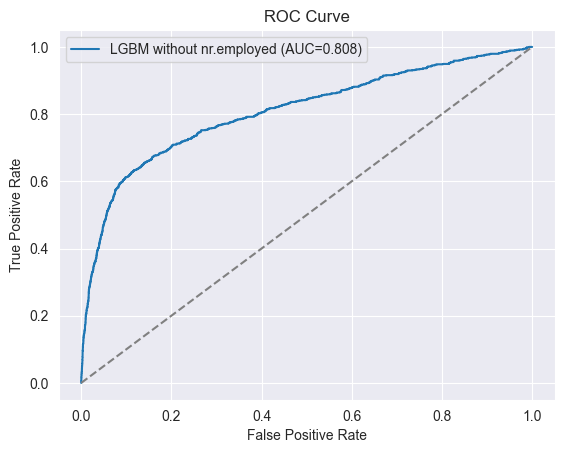

,Model,Params,Train_AUROC,Val_AUROC,Train_F1,Val_F1,Comments
0,LGBM without nr.employed,None,0.8655,0.8081,0.4627,0.3579,None


In [13]:
drop_features = ['nr.employed', 'emp.var.rate', 'euribor3m']

# new column list
input_cols_drop = [col for col in input_cols_lgbm if col not in drop_features]

X_train_d, y_train_d, X_val_d, y_val_d, num_f_d, cat_f_d = prepare_data(
    train_df=train_lgbm,
    val_df=val_lgbm,
    input_cols=input_cols_drop,
    target_col=target_col,
    drop_cols=drop_cols
)

lgbm_drop = create_pipeline(
    model=LGBMClassifier(random_state=42),
    numeric_cols=num_f_d,
    categorical_cols=cat_f_d,
    model_type='lightgbm'
)

lgbm_drop.fit(X_train_d, y_train_d)

evaluate_model(
    'LGBM without nr.employed',
    lgbm_drop,
    X_train_d, y_train_d,
    X_val_d, y_val_d
)

Removing key macroeconomic features ('nr.employed', 'emp.var.rate', 'euribor3m') led to a minor decrease in AUROC, indicating that the model retains its ability to distinguish between classes.
At the same time, a substantial drop in the F1-score is observed, highlighting the important role of these features in detecting the positive class.

Therefore, macroeconomic features significantly enhance the model's ability to identify the positive class.

# SHAP Feature Impact Analysis

To interpret the model, the SHAP library was used. It allows evaluating the contribution of each feature as well as the direction of its impact—whether it increases or decreases the probability of the target class.

100%|===================| 8230/8238 [00:40<00:00]        

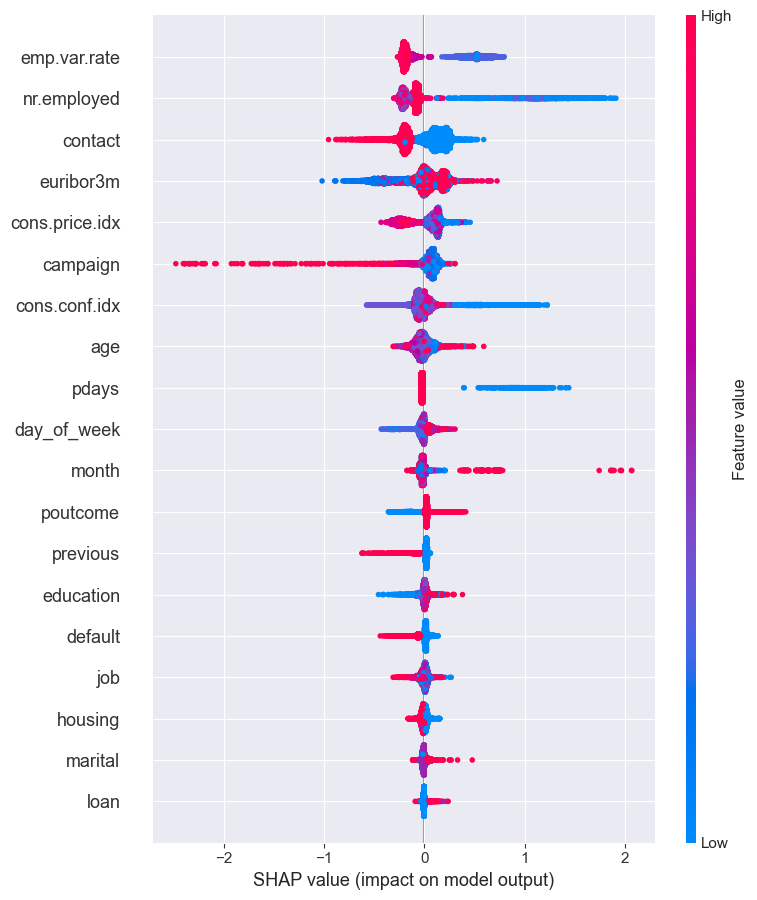

In [14]:
# best model
best_pipeline = lgbm_model

preprocessor = best_pipeline.named_steps['preprocessor']
X_val_transformed = preprocessor.transform(X_val)

feature_names = preprocessor.get_feature_names_out()
feature_names = [f.replace('num__', '').replace('cat__', '') for f in feature_names]

# DataFrame for SHAP
X_val_disp = pd.DataFrame(X_val_transformed, columns=feature_names)

model = best_pipeline.named_steps['model']

# SHAP
explainer = shap.Explainer(model, X_val_transformed)
shap_values = explainer(X_val_transformed)

# vizualisation
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_val_disp)

**Conclusions**

* Macroeconomic indicators have the largest impact on the model's prediction. Their values significantly alter the model's output in terms of increasing or decreasing the probability of the positive class:
  - 'emp.var.rate': lower values more frequently increase the probability of a positive outcome, while higher values decrease it.
  - 'nr.employed': a lower number of employed individuals more frequently coincides with a higher probability of a positive response, while a higher number corresponds to a lower probability.
  - 'euribor3m': lower interest rates increase the probability of a positive outcome, while higher rates decrease it.
  - 'cons.conf.idx': lower values of the consumer confidence index are more often associated with a higher probability of a positive response, while higher values lead to a lower probability.
* Contact intensity ('campaign') shows a noticeable negative impact at high values, which may indicate customer "over-saturation" with communication.
* The feature 'pdays' indicates that clients who were contacted recently have a higher probability of a positive response.
* Categorical features ('month', 'poutcome', 'contact') also influence the outcome, reflecting the results of marketing campaign strategies.


# Analysis of Records Where the Model Makes Errors

In [15]:
# predictions
threshold = best_threshold

y_val_proba = lgbm_model.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_proba >= threshold).astype(int)

# true labels, predicted labels, probabilities
error_df = pd.DataFrame({
    'true_label': y_val,
    'pred_label': y_val_pred,
    'pred_proba': y_val_proba,
}, index=X_val.index)

error_df = error_df.join(val_df.drop(columns=['y', 'y_num']))

# error types
error_df['error_type'] = 'correct'
error_df.loc[(error_df['true_label'] == 1) & (error_df['pred_label'] == 0), 'error_type'] = 'FN'
error_df.loc[(error_df['true_label'] == 0) & (error_df['pred_label'] == 1), 'error_type'] = 'FP'

# list of numerical features for analysis (important ones)
num_cols = ['nr.employed', 'emp.var.rate', 'euribor3m', 'cons.conf.idx',
            'age', 'campaign', 'pdays']

# grouping by error type + mean values of features
summary = error_df.groupby('error_type')[num_cols + ['pred_proba']].mean()

# value counts
summary['count'] = error_df['error_type'].value_counts()

display(summary)

,nr.employed,emp.var.rate,euribor3m,cons.conf.idx,age,campaign,pdays,pred_proba,count
error_type,,,,,,,,,
FN,5124.183308,-1.011684,2.502882,-40.721093,40.065250,2.189681,973.432473,0.540591,659
FP,5022.100746,-2.018657,0.978112,-37.854478,44.417910,1.985075,539.619403,0.900496,134
correct,5174.040739,0.222754,3.780676,-40.504862,39.985359,2.642445,970.988717,0.343586,7445


In [16]:
display(summary)

,nr.employed,emp.var.rate,euribor3m,cons.conf.idx,age,campaign,pdays,pred_proba,count
error_type,,,,,,,,,
FN,5124.183308,-1.011684,2.502882,-40.721093,40.065250,2.189681,973.432473,0.540591,659
FP,5022.100746,-2.018657,0.978112,-37.854478,44.417910,1.985075,539.619403,0.900496,134
correct,5174.040739,0.222754,3.780676,-40.504862,39.985359,2.642445,970.988717,0.343586,7445


## **Conclusions**
The model:
* overestimates the probability of 'yes' and makes false-positive predictions under favorable economic conditions
* identifies 'yes' cases less accurately under worse economic conditions
* underestimates positive cases among younger clients with relatively low economic indicators

To improve the model, the following steps can be taken:
- adjust the classification threshold
- balance the dataset
- further investigate cases with low 'euribor3m' values
- add features that better describe economic status
- analyze the behavior of new clients whose interactions the model often mistakenly classifies as unsuccessful
